# Homework I. Entropy and Probability
## Teresa Puyol López

The file compiled and with all the results can be founded in my GitHub:


https://github.com/teresa-p-l/Complex-Systems/blob/dc06f12845e7eeab57c9cf0b8135e505a7007f13/entrega1/Homework1_TeresaPuyol.ipynb


# 1. Entropy

- Create several files with 1-million one-digit numbers and diﬀerent amount of randomness as
    - A deterministic one in the format “11111111”.
    - A total random one.
    - One where the probability of a number is proportional to the number itself.
    - Any other distribution you can think of.
- Calculate Shannon’s entropy of the ﬁles.
- Compress the ﬁles with ZIP and calculate the compression ratio.
- Plot the compression ratio against Shanon’s entropy. What is the relation between these two
quantities?
- Try to ﬁnd a protocol that “cheats”, meaning that it has a high entropy but it can be eﬃciently
compressed.

In [62]:
import numpy as np
import matplotlib.pyplot as plt



# First we create the different files required:

tags = [] # array that saves everything
N = 1000000

# Function that saves the number distribution in a text file
def save(filename, digits):
    with open(filename, "w") as f:
        f.write("".join(map(str, digits)))




# 1. 111111
determ_file = "deterministic.txt"
determ_num = np.ones(N, dtype=int)
save(determ_file, determ_num)
tags.append(("Deterministic", determ_file, determ_num))

# 2.  Random 
rand_file = "random.txt"
rand_num = np.random.randint(0,10, size=N)
save(rand_file, rand_num)
tags.append(("Random", rand_file, rand_num))


# 3. Probability of a number proportional to the number
prop_file = "proportional.txt"
prop_num = np.random.choice(np.arange(10), size=N, p=np.arange(10)/45)
save(prop_file, prop_num)
tags.append(("Proportional", prop_file, prop_num))


# 4. Another distribution: proportional to the square root of the number
sqrt_file = "squared.txt"
sqrt_num = np.random.choice(np.arange(10), size=N, p=np.sqrt(np.arange(10))/np.sum(np.sqrt(np.arange(10))))
save(sqrt_file, sqrt_num)
tags.append(("Squared", sqrt_file, sqrt_num))

# 5. Cheat, 0123456789 sequence repeating
cheat_file = "cheat.txt"
cheat_num = np.tile(np.arange(10), N//10)
save(cheat_file, cheat_num)
tags.append(("Cheat", cheat_file, cheat_num)) 




We calculate Shanon's entropy as:
$$ S = -\sum P_i log(P_i) $$

In [63]:
# As we have to calculate Shanon's entropy for each file, we make a funcion that calculates it 

def shanon(digits):
    numbers, times = np.unique(digits, return_counts=True)
    probabilities = times / N
    entropy = -np.sum(probabilities * np.log10(probabilities))
    return entropy

# We also need to compress the files so we import the following library
import zipfile

def zip_file(filename):
    #zipfile.ZipFile(filename.replace(".txt", ".zip"), "w").write(filename)
    zipfile.ZipFile(filename.replace(".txt", ".zip"), "w", compression=zipfile.ZIP_DEFLATED).write(filename)
    # voy a probar a hacerlo sin meter eso


# To get the copression ratio I'm going to use the following function

import os

def compression_ratio(filename):
    original_size = os.path.getsize(filename)
    compressed_size = os.path.getsize(filename.replace(".txt", ".zip"))
    return compressed_size / original_size


# Now we use calculate everything

names = []
entropies = []
ratios = []

for name, filename, digits in tags:
    names.append(name)
    entropies.append(shanon(digits))
    zip_file(filename)
    ratios.append(compression_ratio(filename))

    

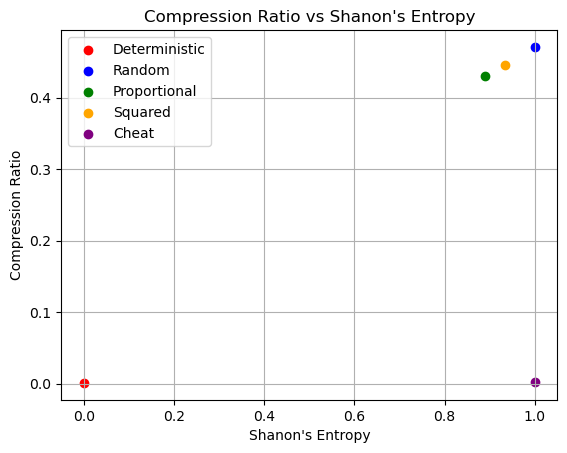

In [64]:
# Plotting the compression ratio against entropy

colors = ["red", "blue", "green", "orange", "purple"]

for i in range(len(names)):
    plt.scatter(entropies[i], ratios[i], color=colors[i], label=names[i])

plt.xlabel("Shanon's Entropy")
plt.ylabel("Compression Ratio")
plt.title("Compression Ratio vs Shanon's Entropy")
plt.legend()
plt.grid()
plt.show()

# 2. Look in the media for a misuse of a statistical concept. Explain why it is wrong.

A common misuse of a statistical concept in the media is the incorrect interpretation of causation and correlation.

This happens when two variables are presented as cause and effect, when in reality they may both be consequences of another factor or they may not be related at all.

One well-known example of this happening is the graph that relates the number of people who died in shark attacks with sunscreen sales. In this case, both variables increase at the same time because of summer, but neither has any real effect on the other.

Another headline that I encountered in the media is the alleged relationship between autism (or other neurological conditions) in children and the consumption of Tylenol (Paracetamol) during pregnancy. 
However, there is no real evidence that shows that the consumption of Tylenol causes these conditions. One possible explanation for this finding is that pregnancies with complications are usually more painful, and therefore, can lead to an increase in Tylenol consumption. 

So, in the end, the relationship is not cause and effect but rather two consequences of a third factor.

# 3. Properties of binomial distribution (1/4 points)

For binomial distribution, $p_n(k) = \binom{n}{k} p^k (1-p)^{n-k}$ prove that: 
1. The Moment Generating Function is $(q + pe^t)^n$, where $ q = 1 − p$.
2. The mean is $E[X] = np.$
3. The variance is $ Var(X) = np(1 − p).$

The moment generating function can be calculated as 
$$ M_X(t)= E[exp(tX)]\;\;\; where\;\;\; E[f(x)]= \sum_{i=1}^n f(x_i)P_i $$

So, if we substitute: 
$$ M_X(t)= \sum_{k=0}^n  e^{tk} P_n(k) = \sum_{k=0}^n  \binom{n}{k} (pe^t)^k q^{n-k} $$

And, to take away the combinatory number we use the Newton's Binomial:

$$ (a+b)^n = \sum_{k=0}^n \binom{n}{k} a^{n-k}b^k $$

If $a=q$ and $b=pe^t$ then we have that $ M_X(t)= (q+pe^t)^n  $  where $q=1-p$


To calculate the mean we do something similar as before:

$$ E[x]= \sum_{i=1}^n k P_i = \sum_{k=0}^n  k \binom{n}{k} p^k q^{n-k} = \sum_{k=1}^n  k \binom{n}{k} p^k q^{n-k}  $$

And, $ k \binom{n}{k} = \frac{n!}{(k-1)!(n-k)!} = n \binom{n-1}{k-1}   $

then $ E[x]=  \sum_{k=1}^n  np \binom{n-1}{k-1}p^{k-1} q^{n-k}   $ 

To change with the Newton's Binomial we do the change $ m = k-1 \;\Rightarrow \; k = m+1$

$$ E[x]=  \sum_{m=0}^{n-1}  np \binom{n-1}{m} p^m q^{(n-1)-m} =  np(p+q)^{n-1} =np $$

As $p+q=p+1-p=1$



To calculate the variance: $Var(X) =  E[(x-E[x]^2)]= E[x^2] - (E[x])^2$
We will need to internchange factorials, so its easier to work with $x(x-1)+x$ than $x^2$, so we present the variance as $Var(X) =E[x(x-1)] +E[x] - (E[x])^2$, and we already have the two latter terms ( $ E[x]=np$ )

$$ E[x(x-1)]= \sum_{k=0}^n  k(k-1) \binom{n}{k} p^k q^{n-k} = \sum_{k=2}^n  k(k-1) \binom{n}{k} p^k q^{n-k}$$

And, $ k(k-1) \binom{n}{k} = \frac{n!}{(k-2)!(n-k)!} = n(n-1) \binom{n-2}{k-2}   $

then $ E[x(x-1)]=  \sum_{k=2}^n  n(n-1)p^2 \binom{n-2}{k-2}p^{k-2} q^{n-k} = \sum_{l=0}^{n-2} n(n-1)p^2 \binom{n-2}{l}p^{l} q^{(n-2)-l} $ 

where $k-2=l \;\Rightarrow \; k = m+2$ 

So, with the Binomial we get that $E[x(x-1)]= n(n-1)p^2 $

We end up with: 
$$ Var(x) = p^2n(n-1) + np - (np)^2 = np(1-p)$$

# 4. Central Limit Theorem 

Let $X_i$, $i \in \mathbb{N}$ be independent, identically distributed (i.i.d.) random variables with mean $\mu$ and variance $\sigma^2 < \infty$. Let $S_n$ be the random variable describing the partial sums of the sequence $\{X_i\}_{i \in \mathbb{N}}$:
\[
S_n=\sum_i X_i.
\]
You have to prove that:
\begin{equation}
Z_n=\frac{S_n-E[S_n]}{\sigma(S_n)}
=\frac{S_n-n\mu}{\sigma\sqrt{n}}
\end{equation}
converges to a standard normal random variable as $n$ goes to infinity. For that, follow these steps:


 1.  Prove that:
    \begin{equation}
    M_{Z_n}(t)=\left[M_{Y_1}\left(\frac{t}{\sqrt{n}}\right)\right]^n
    \end{equation}
    where $Y_i$ is the random variable:
    \begin{equation}
    Y_i=\frac{X_i-\mu}{\sigma}
    \end{equation}
    centered and standardized. To keep the notation simple, from now on, just write: $M_Y(t)$ instead of $M_{Y_1}(t)$.

 2.  Prove that:
    \begin{equation}
    M_Y(t)=1+\frac{1}{2}t^2+o(t^3)
    \end{equation}
    Plug this into the equation for $M_{Z_n}(t)$. Take the limit when $n \to \infty$ to get:
    \begin{equation}
    M_{Z_n}(t)\to \exp\left(\frac{t^2}{2}\right)
    \end{equation}

3.  Conclude that $Z_n$ converges to a standard normal random variable.

4.  As a numerical test, generate samples of i.i.d.\ random variables with different distributions (Bernoulli, Uniform, etc.) and test that the standardized sum of all of them, $Z_n$, is distributed as a Gaussian in the limit $n \to \infty$.


1- To prove that $M_{Z_n}(t)=\left[M_{Y_1}\left(\frac{t}{\sqrt{n}}\right)\right]^n$ let's try to rewrite $Z_n$

$x_i-\mu = \sigma Y_i \;\;\;$  and  $\;\;\;S_n = \sum_i x_i\;$   $\Rightarrow\;$   $S_n - \mu_n = \sum_{i=1}^n (x_i - \mu) = \sigma  \sum_{i=1}^n Y_i$

Then $$Z_n = \sum_{i=1}^n \frac{Y_i}{\sqrt{n}}$$

Now we calculate the Moment generating function $$ M_{Z_n}(t) = E[e^{tZ_n}]=E[e^{ \sum_{i=1}^n \frac{t}{\sqrt{n}} Y_i }] = E[e^{tZ_n}]=E[\prod_{i=1}^n e^{ \frac{t}{\sqrt{n}} Y_i }] $$

As $x_i$ and $i$ are independent we can calculate the product of the expectation values instead of the expectation value of the product. As they are also identically distributed, the expectation value for each $i$ is the same, so instead of doing the product we can take the n-th power. It looks like:
$$ M_{Z_n}(t)=(E[e^{ \frac{t}{\sqrt{n}} Y_i }])^n $$

By definition of the moment generating function: $$M_X(t)= E[exp(tX)]\;\; \Rightarrow \;\; M_Y(\frac{t}{\sqrt{n}}) =  E[e^{\frac{t}{\sqrt{n}} Y}] $$

Combining the last two results we get that:

$$ M_{Z_n}(t) = [M_Y(\frac{t}{\sqrt{n}})]^n  $$



2-  To prove that, let's start by analyzing the power series of the exponential: $e^{tY} = 1+tY+ \frac{t^2 Y^2 }{2} $

And, plugging that into the moment generating function: 

$ M_Y(t) =  E[e^{t Y}] =  E[1+tY+ \frac{t^2 Y^2 }{2}] = E[1] + E[tY] + E[\frac{t^2 Y^2 }{2}] = E[1] + tE[Y] + \frac{t^2}{2}E[Y^2] $

Let's calculate the expectation values:
- $E[1]=0$
- As $Y = \frac{x- \mu}{\sigma }\;\;\Rightarrow \;\; E[Y]=\frac{E[x]- \mu}{\sigma} = 0$ ($\mu = E[x]$)
- As $Var(x) = E[Y^2]$  and $Var(Y)=Var(\frac{x- \mu}{\sigma }) = \frac{\sigma^2}{\sigma^2}=1$ 

Then: 
$$  M_Y(t) = 1 + 0 + \frac{t^2}{2} \;\;\Rightarrow \;\; M_{Z_n}(t)= (1 + \frac{t^2}{2})^n $$ 

Now we take the limit:
$$\lim_{n\to\infty} M_{Z_n}(t) =\lim_{n\to\infty} (1 + \frac{t^2}{2})^n = e^\frac{t^2}{2} $$

3- The moment generating function (MGF) of a distribution is unique. This means that, if two distributions have the same MGF, they are the same distribution.

The MGF of our distribution is $M_{Z_n}(t) \to e^\frac{t^2}{2}$ when $n\to \infty$

And, the MGF of a standard normal random variable $N(0,1)$ is $M_{N(0,1)}(t) = e^\frac{t^2}{2} $

As both MGF are equal, we can say conclude that $Z_n$ concludes to a standard normal random variable

4- Now we need to do a numerical test to see if, for different i.i.d distributions (Bernoulli, Uniform ...), $ Z_n = \frac{S_n - n\mu}{\sigma \sqrt{n}}$ becomes $N(0,1)$ (a Gaussian distribution) when $n \to \infty$

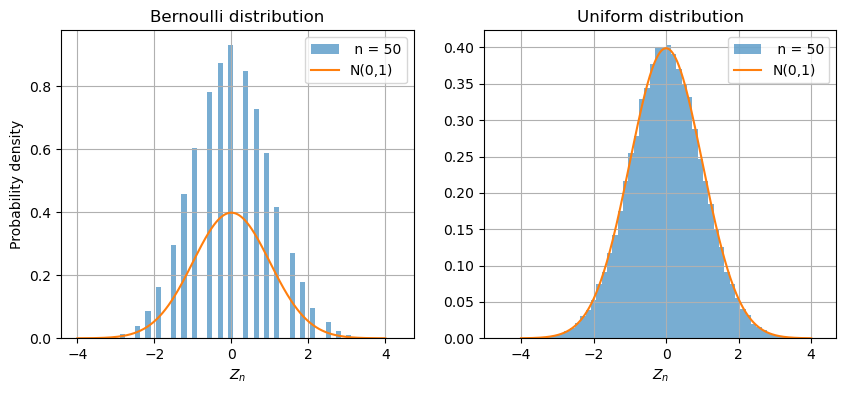

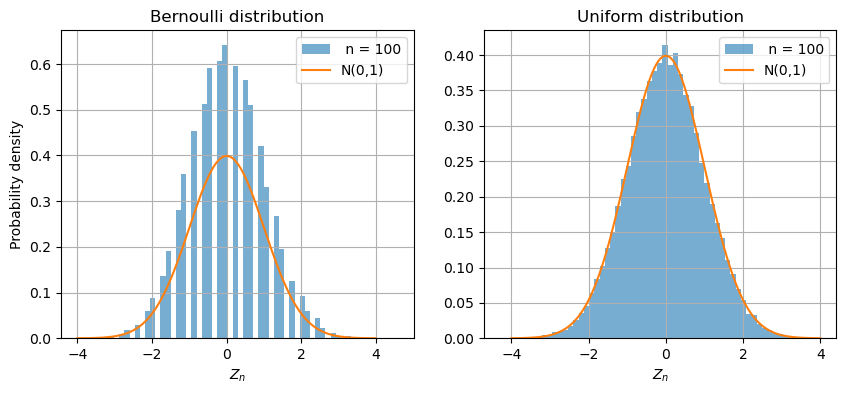

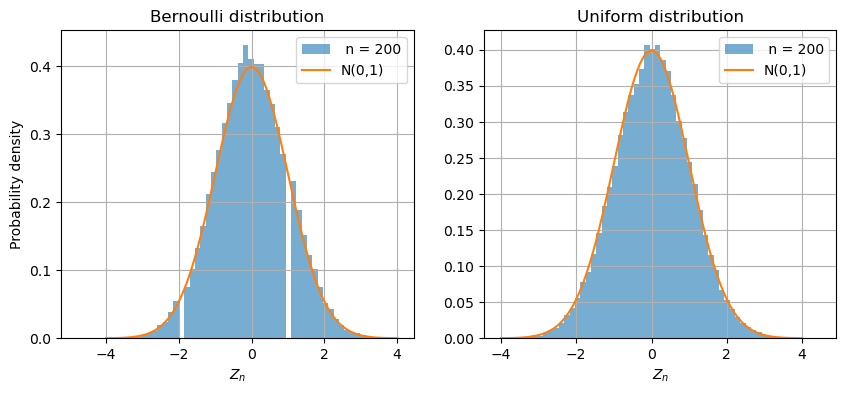

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


samples = 50000
n = [50, 100, 200]


for i in range(len(n)):
    # 1. Bernoulli distribution
    p = 0.3
    X = np.random.binomial(1, p, size=(samples, n[i]))
    sigma = np.sqrt(p*(1-p))
    S = np.sum(X, axis=1)
    Z = (S - n[i]*p)/(sigma*np.sqrt(n[i]))

    x = np.linspace(-4, 4, 400)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(Z, bins=60, density=True, alpha=0.6, label=rf' n = {n[i]}')
    plt.plot(x, norm.pdf(x), label='N(0,1)')
    plt.title('Bernoulli distribution')
    plt.xlabel(r'$Z_n$')
    plt.ylabel('Probability density')
    plt.legend()
    plt.grid()

    # 2. Uniform distribution
    a, b = 0, 1
    X = np.random.uniform(a, b, size=(samples, n[i]))
    mu = (a+b)/2
    sigma = np.sqrt((b-a)**2/12)
    S = np.sum(X, axis=1)
    Z = (S - n[i]*mu)/(sigma*np.sqrt(n[i]))

    plt.subplot(1,2,2)
    plt.hist(Z, bins=60, density=True, alpha=0.6, label=rf' n = {n[i]}')
    plt.plot(x, norm.pdf(x), label='N(0,1)')
    plt.title('Uniform distribution')
    plt.xlabel(r'$Z_n$')
    plt.legend()
    plt.grid()


plt.show()



We can see that as $n \to \infty$, the distribution becomes more like a normal distribution.